In [ ]:
# Atividade - Correlação

# Verificar se existe correlação entre os roubos e recuperação de veículos 
# através das DPs e se é possível observar se as recuperações acompanham os roubos.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ENDERECO_DADOS = 'https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv'

# Carregar dados

try:
    print('Obtendo dados')
    # Recebendo dados do arquivo CSV
    df_ocorrencias = pd.read_csv(ENDERECO_DADOS, sep=';', encoding='iso-8859-1')

    # Delimitando as variáveis para CISP, roubo_veiculo e recuperacao_veiculos
    df_roubo_veiculo = df_ocorrencias[['cisp', 'roubo_veiculo','recuperacao_veiculos']]

    # Agrupando os dados por CISP e somando os valores de roubo_veiculo e recuperacao_veiculos
    df_total_roubos = df_roubo_veiculo.groupby('cisp', as_index=False)[['roubo_veiculo', 'recuperacao_veiculos']].sum()

    print(df_total_roubos.head())

except Exception as e:
    print(f'Erro ao carregar dados: {e}')

In [2]:
# Correlação
try:
    print('Calculando correlação')
    correlacao = np.corrcoef(df_total_roubos.roubo_veiculo, df_total_roubos.recuperacao_veiculos)[0, 1]
    print(f'Correlação é de {correlacao:.4f}')

except Exception as e:
    print(f'Erro ao calcular correlação: {e}')

Calculando correlação
Correlação é de 0.9283


Criando gráfico de dispersão


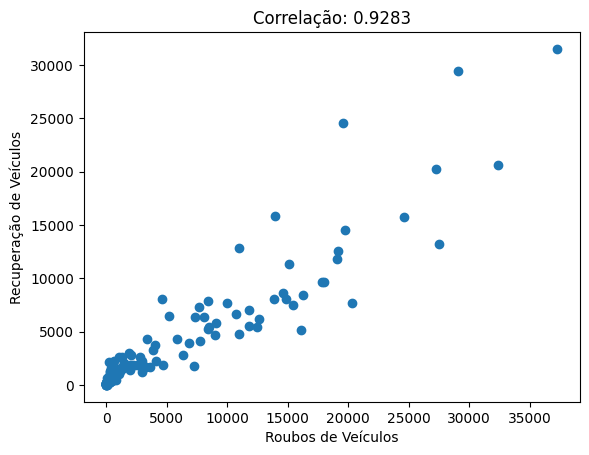

In [3]:
# Gráfico  de dispersão
try:
    print('Criando gráfico de dispersão')
    plt.scatter(df_total_roubos['roubo_veiculo'], df_total_roubos['recuperacao_veiculos'])
    plt.title(f'Correlação: {correlacao:.4f}')
    plt.xlabel('Roubos de Veículos')
    plt.ylabel('Recuperação de Veículos')
    plt.show()

except Exception as e:
    print(f'Erro ao plotar gráfico: {e}')